## 0. Setup & Load Data

Notebook ini melakukan Exploratory Data Analysis (EDA) pada `application_train.csv` 
sebagai bagian dari Home Credit Default Risk project. Fokus EDA: memahami distribusi 
target, kualitas data (missing value), pola fitur numerik & kategorikal terhadap risiko 
default, serta mendeteksi anomali yang perlu ditangani di tahap Data Cleaning.

Library utama: pandas untuk manipulasi data, matplotlib & seaborn untuk visualisasi.

# Konfigurasi Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

df = pd.read_csv("../data/raw/application_train.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,Ho

# Distribusi & Imbalance Ratio TARGET

Tujuan: mengetahui seberapa timpang proporsi klien default (TARGET=1) vs tidak default 
(TARGET=0). Rasio yang sangat timpang berdampak pada pemilihan metrik evaluasi 
(accuracy jadi tidak reliable) dan strategi handling imbalance (class_weight, SMOTE) 
di tahap modeling nanti.

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


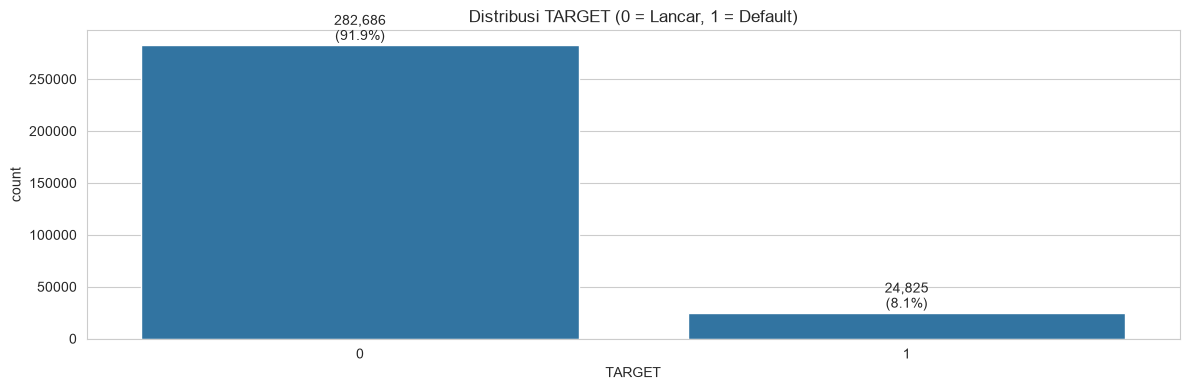

In [2]:
target_counts = df["TARGET"].value_counts()
target_pct = df["TARGET"].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(12, 4))
sns.countplot(x="TARGET", data=df, ax=ax)
ax.set_title("Distribusi TARGET (0 = Lancar, 1 = Default)")
for i, v in enumerate(target_counts):
    ax.text(i, v + 5000, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png", dpi=150)
plt.show()

# Missing Value Map

Tujuan: mengidentifikasi kolom dengan proporsi missing value tinggi untuk menentukan 
strategi imputasi atau kandidat drop kolom. Kolom dengan missing >50% sering butuh 
perlakuan khusus (misal: dijadikan flag "is_missing" karena missingness-nya sendiri 
bisa informatif, bukan sekadar noise).

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"Jumlah kolom dengan missing value: {len(missing_df)} dari {df.shape[1]} kolom")
missing_df.head(20)

Jumlah kolom dengan missing value: 67 dari 122 kolom


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


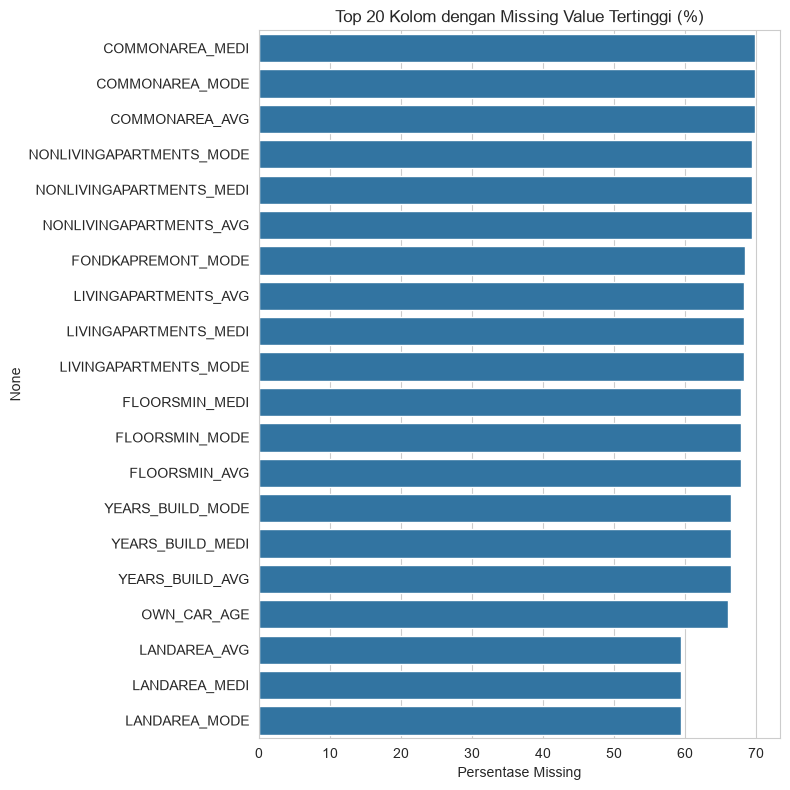

In [4]:
top20_missing = missing_df.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top20_missing["missing_pct"], y=top20_missing.index, ax=ax)
ax.set_title("Top 20 Kolom dengan Missing Value Tertinggi (%)")
ax.set_xlabel("Persentase Missing")
plt.tight_layout()
plt.savefig("../reports/figures/02_missing_values.png", dpi=150)
plt.show()

# Cek Linearitas — Bandingkan Pearson vs Spearman (tidak relate karena make IV)

tujuan: untuk di chek apakah lebih baik memakai heatmap karena linear atau tidaknya karena jika tidak linear tidak di sarankan memakai heatmap


In [5]:
# numeric_features_filled_for_check = numeric_features.fillna(numeric_features.median())

# pearson_corr = numeric_features_filled_for_check.corrwith(df["TARGET"], method="pearson").abs()
# spearman_corr = numeric_features_filled_for_check.corrwith(df["TARGET"], method="spearman").abs()

# linearity_check = pd.DataFrame({
#     "pearson": pearson_corr,
#     "spearman": spearman_corr
# })
# linearity_check["gap"] = linearity_check["spearman"] - linearity_check["pearson"]
# linearity_check_sorted = linearity_check.sort_values("gap", ascending=False)

# print("Fitur dengan gap Spearman-Pearson terbesar (indikasi non-linear/non-monoton simetris terlewat):")
# print(linearity_check_sorted.head(15))

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.scatter(linearity_check["pearson"], linearity_check["spearman"], alpha=0.6)
# ax.plot([0, linearity_check.max().max()], [0, linearity_check.max().max()], "r--", label="Pearson = Spearman")
# ax.set_xlabel("Pearson |corr|")
# ax.set_ylabel("Spearman |corr|")
# ax.set_title("Pearson vs Spearman — Titik jauh dari garis merah = non-linear")
# ax.legend()
# plt.tight_layout()
# plt.savefig("../reports/figures/02e_pearson_vs_spearman.png", dpi=150)
# plt.show()

# Heatmap dan Mutual Information untuk Kolom dengan Missing Value

Tujuan: sebelum memutuskan drop kolom manapun, kita visualisasikan dulu seberapa 
kuat korelasi setiap kolom yang punya missing value terhadap TARGET. 

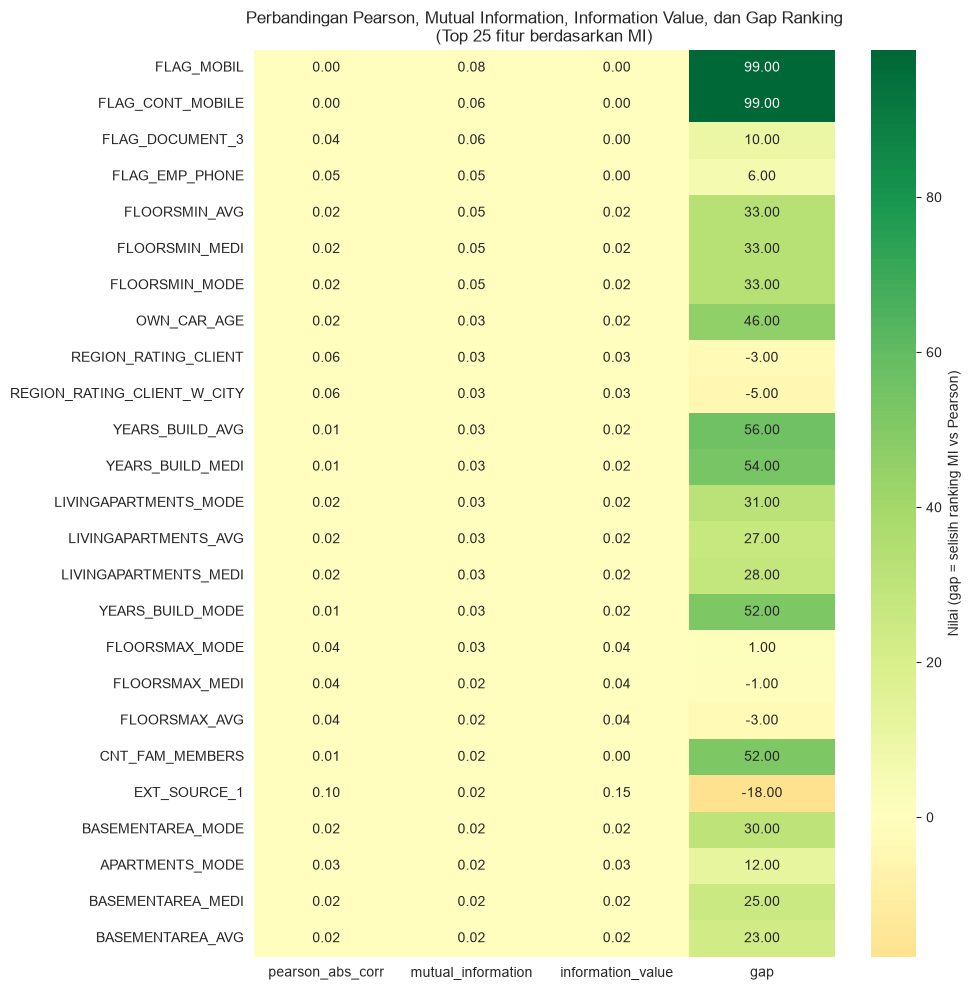

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif


def calculate_iv(series, target, bins=10, epsilon=1e-6):
    """
    Hitung Information Value (IV) untuk satu fitur terhadap target biner.
    Missing value diperlakukan sebagai bin tersendiri.
    """
    df_temp = pd.DataFrame({"feature": series.values, "target": target.values})
    missing_mask = df_temp["feature"].isna()
    parts = []

    non_missing = df_temp[~missing_mask].copy()
    if len(non_missing) > 0:
        try:
            non_missing["bin"] = pd.qcut(non_missing["feature"], q=bins, duplicates="drop")
        except ValueError:
            non_missing["bin"] = non_missing["feature"]
        parts.append(non_missing[["bin", "target"]])

    if missing_mask.sum() > 0:
        missing_part = df_temp[missing_mask].copy()
        missing_part["bin"] = "Missing"
        parts.append(missing_part[["bin", "target"]])

    if not parts:
        return np.nan

    combined = pd.concat(parts, ignore_index=True)
    grouped = combined.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_bad = grouped["bad"].sum()
    total_good = grouped["good"].sum()

    grouped["dist_bad"] = (grouped["bad"] + epsilon) / (total_bad + epsilon)
    grouped["dist_good"] = (grouped["good"] + epsilon) / (total_good + epsilon)
    grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
    grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

    return grouped["iv_component"].sum()


# ===== STEP 1: Buat comparison_df dari awal =====
# Ambil semua kolom numerik kecuali SK_ID_CURR dan TARGET
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=["SK_ID_CURR", "TARGET"])
feature_cols = numeric_features.columns.tolist()

# Isi missing value dengan median untuk perhitungan korelasi & MI
numeric_filled = numeric_features.fillna(numeric_features.median())

# Hitung Pearson correlation (absolute)
pearson_corr = numeric_filled.corrwith(df["TARGET"], method="pearson").abs()

# Hitung Mutual Information
mi_scores = mutual_info_classif(numeric_filled, df["TARGET"], random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols)

# Buat comparison_df
comparison_df = pd.DataFrame({
    "pearson_abs_corr": pearson_corr,
    "mutual_information": mi_series
})

# Hitung gap ranking
comparison_df["pearson_rank"] = comparison_df["pearson_abs_corr"].rank(ascending=False)
comparison_df["mi_rank"] = comparison_df["mutual_information"].rank(ascending=False)
comparison_df["gap"] = comparison_df["pearson_rank"] - comparison_df["mi_rank"]

# ===== STEP 2: Hitung IV =====
iv_values = {
    col: calculate_iv(df[col], df["TARGET"], bins=10)
    for col in comparison_df.index
    if col in df.columns
}
comparison_df["information_value"] = pd.Series(iv_values)

# ===== STEP 3: Visualisasi =====
comparison_display = comparison_df.dropna(subset=["information_value"]).copy()
comparison_display["iv_rank"] = comparison_display["information_value"].rank(ascending=False)
comparison_display_sorted = comparison_display.sort_values("mutual_information", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    comparison_display_sorted[["pearson_abs_corr", "mutual_information", "information_value", "gap"]],
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    yticklabels=comparison_display_sorted.index, ax=ax,
    cbar_kws={"label": "Nilai (gap = selisih ranking MI vs Pearson)"}
)
ax.set_title("Perbandingan Pearson, Mutual Information, Information Value, dan Gap Ranking\n(Top 25 fitur berdasarkan MI)")
plt.tight_layout()
plt.savefig("../reports/figures/02f_combined_heatmap.png", dpi=150)
plt.show()


# Information Value (IV) — Metrik Utama Seleksi Fitur

In [7]:
def calculate_iv(series, target, bins=10, epsilon=1e-6):
    df_temp = pd.DataFrame({"feature": series.values, "target": target.values})
    missing_mask = df_temp["feature"].isna()
    parts = []

    non_missing = df_temp[~missing_mask].copy()
    if len(non_missing) > 0:
        if pd.api.types.is_numeric_dtype(non_missing["feature"]):
            try:
                non_missing["bin"] = pd.qcut(non_missing["feature"], q=bins, duplicates="drop")
            except ValueError:
                non_missing["bin"] = non_missing["feature"]
        else:
            non_missing["bin"] = non_missing["feature"].astype(str)
        parts.append(non_missing[["bin", "target"]])

    if missing_mask.sum() > 0:
        missing_part = df_temp[missing_mask].copy()
        missing_part["bin"] = "Missing"
        parts.append(missing_part[["bin", "target"]])

    if not parts:
        return np.nan

    combined = pd.concat(parts, ignore_index=True)
    grouped = combined.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_bad = grouped["bad"].sum()
    total_good = grouped["good"].sum()

    grouped["dist_bad"] = (grouped["bad"] + epsilon) / (total_bad + epsilon)
    grouped["dist_good"] = (grouped["good"] + epsilon) / (total_good + epsilon)
    grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
    grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

    return grouped["iv_component"].sum()

# Menghitung IV untuk Semua Kolom (Numerik + Kategorikal)

In [8]:
def categorize_iv(iv):
    if iv < 0.02:
        return "Useless"
    elif iv < 0.1:
        return "Weak"
    elif iv < 0.3:
        return "Medium"
    elif iv < 0.5:
        return "Strong"
    else:
        return "Suspicious"


numeric_cols_for_iv = df.select_dtypes(include=[np.number]).drop(columns=["SK_ID_CURR", "TARGET"]).columns.tolist()
categorical_cols_for_iv = df.select_dtypes(include="object").columns.tolist()
all_cols_for_iv = numeric_cols_for_iv + categorical_cols_for_iv


iv_results_all = {col: calculate_iv(df[col], df["TARGET"], bins=10) for col in all_cols_for_iv}


iv_df_all = pd.DataFrame({"information_value": pd.Series(iv_results_all)})
iv_df_all["dtype"] = ["numeric" if col in numeric_cols_for_iv else "categorical" for col in iv_df_all.index]
iv_df_all["category"] = iv_df_all["information_value"].apply(categorize_iv)
iv_df_all = iv_df_all.sort_values("information_value", ascending=False)


print(f"Total fitur dianalisis (numerik + kategorikal): {len(iv_df_all)}")
print(iv_df_all.head(30))

C:\Users\USER\AppData\Local\Temp\ipykernel_21396\3133973843.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_for_iv = df.select_dtypes(include="object").columns.tolist()


Total fitur dianalisis (numerik + kategorikal): 120
                              information_value        dtype category
EXT_SOURCE_3                           0.329443      numeric   Strong
EXT_SOURCE_2                           0.306473      numeric   Strong
EXT_SOURCE_1                           0.150934      numeric   Medium
DAYS_EMPLOYED                          0.101263      numeric   Medium
AMT_GOODS_PRICE                        0.091941      numeric     Weak
DAYS_BIRTH                             0.084200      numeric     Weak
OCCUPATION_TYPE                        0.082865  categorical     Weak
ORGANIZATION_TYPE                      0.073368  categorical     Weak
NAME_INCOME_TYPE                       0.059715  categorical     Weak
NAME_EDUCATION_TYPE                    0.050836  categorical     Weak
DAYS_LAST_PHONE_CHANGE                 0.046729      numeric     Weak
AMT_CREDIT                             0.045073      numeric     Weak
CODE_GENDER                           

# Visualisasi Ranking IV

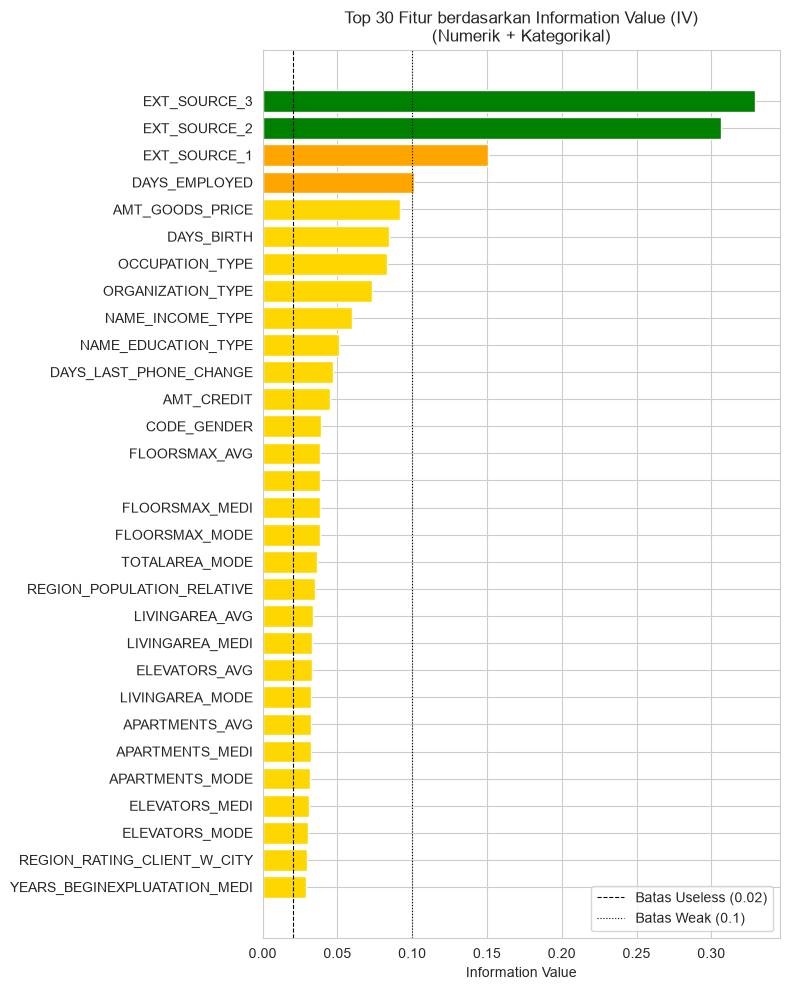

In [34]:
top30_iv = iv_df_all.dropna().head(30)

fig, ax = plt.subplots(figsize=(8, 10))
colors = top30_iv["category"].map({
    "Suspicious (cek data leakage)": "darkred",
    "Strong": "green",
    "Medium": "orange",
    "Weak": "gold",
    "Useless": "gray"
})
ax.barh(top30_iv.index, top30_iv["information_value"], color=colors)
ax.axvline(0.02, color="black", linestyle="--", linewidth=0.8, label="Batas Useless (0.02)")
ax.axvline(0.1, color="black", linestyle=":", linewidth=0.8, label="Batas Weak (0.1)")
ax.invert_yaxis()
ax.set_xlabel("Information Value")
ax.set_title("Top 30 Fitur berdasarkan Information Value (IV)\n(Numerik + Kategorikal)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/02g_iv_ranking.png", dpi=150)
plt.show()

# Rekap Kandidat Drop

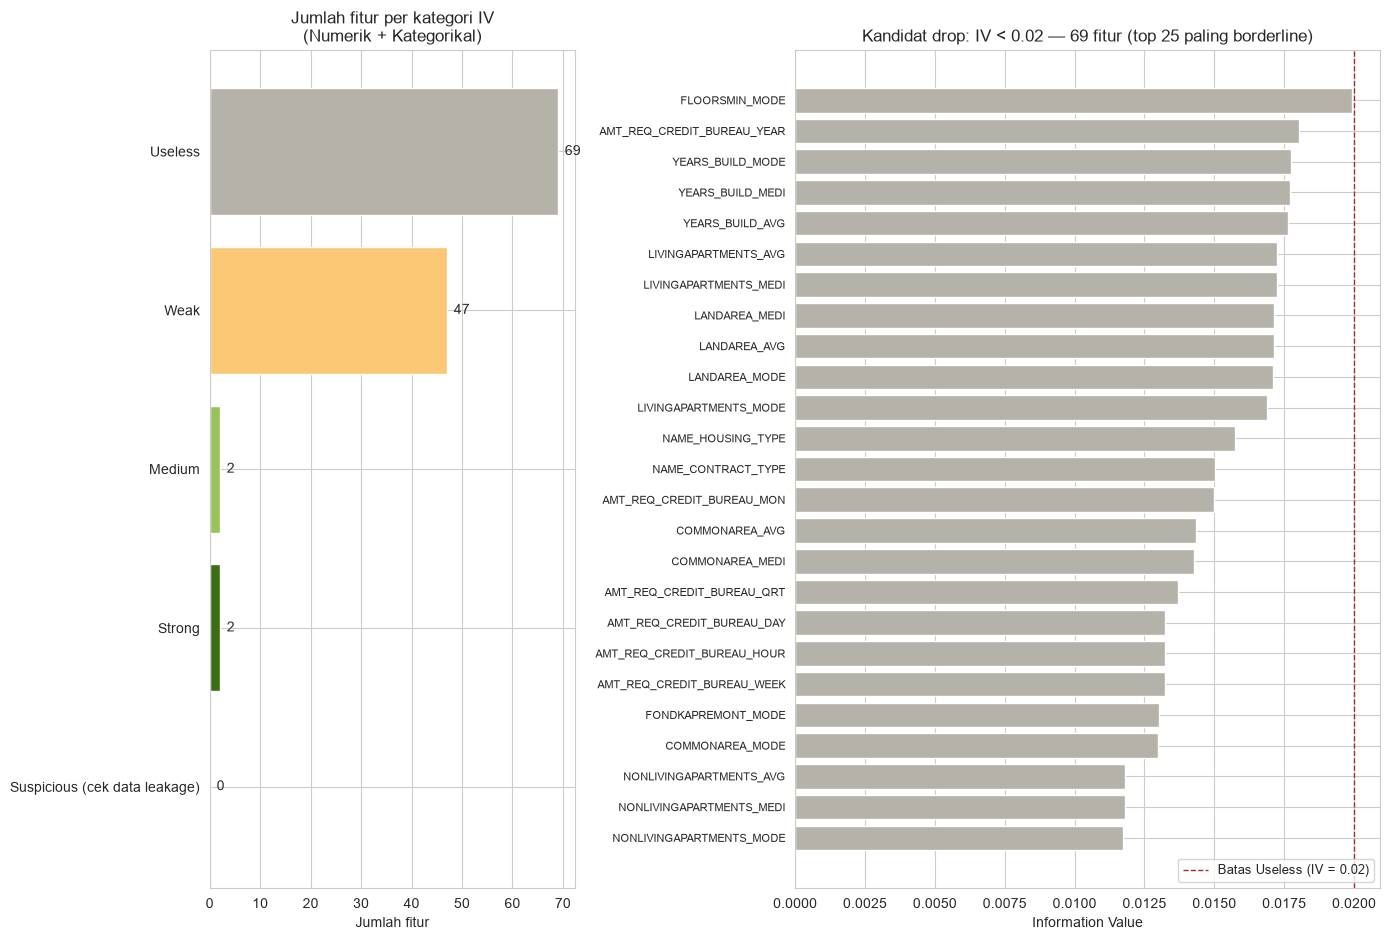

Catatan: 44 fitur lain dengan IV mendekati 0 tidak ditampilkan di panel kanan (tidak informatif untuk divisualkan satu-satu).


In [10]:
drop_candidates = iv_df_all[iv_df_all["category"] == "Useless"].index.tolist()

category_order = ["Useless", "Weak", "Medium", "Strong", "Suspicious (cek data leakage)"]
category_colors = {
    "Useless": "#B4B2A9",
    "Weak": "#FAC775",
    "Medium": "#97C459",
    "Strong": "#3B6D11",
    "Suspicious (cek data leakage)": "#A32D2D",
}

drop_df = iv_df_all.loc[drop_candidates].sort_values("information_value", ascending=True)
n_show = min(len(drop_df), 25)
drop_df_show = drop_df.tail(n_show)

fig_height = max(6, 0.3 * n_show + 2)
fig, axes = plt.subplots(1, 2, figsize=(14, fig_height), gridspec_kw={"width_ratios": [1, 1.6]})

category_counts = iv_df_all["category"].value_counts().reindex(category_order).fillna(0)
bars = axes[0].barh(
    category_counts.index,
    category_counts.values,
    color=[category_colors[c] for c in category_counts.index],
)
axes[0].set_title("Jumlah fitur per kategori IV\n(Numerik + Kategorikal)")
axes[0].set_xlabel("Jumlah fitur")
axes[0].invert_yaxis()
for bar, value in zip(bars, category_counts.values):
    axes[0].text(
        bar.get_width() + category_counts.values.max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center", fontsize=10,
    )

axes[1].barh(drop_df_show.index, drop_df_show["information_value"], color=category_colors["Useless"])
axes[1].axvline(0.02, color="#A32D2D", linestyle="--", linewidth=1, label="Batas Useless (IV = 0.02)")
title_suffix = f" (top {n_show} paling borderline)" if len(drop_df) > n_show else ""
axes[1].set_title(f"Kandidat drop: IV < 0.02 — {len(drop_candidates)} fitur{title_suffix}")
axes[1].set_xlabel("Information Value")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/02g_iv_drop_candidates.png", dpi=150, bbox_inches="tight")
plt.show()

if len(drop_df) > n_show:
    print(f"Catatan: {len(drop_df) - n_show} fitur lain dengan IV mendekati 0 tidak ditampilkan di panel kanan (tidak informatif untuk divisualkan satu-satu).")

# Missing Value % 

Jumlah kolom Weak  : 47
Jumlah kolom Medium: 2
Jumlah kolom Strong: 2

 [STRONG (IV ≥ 0.3)] Missing Value — 2 kolom
              missing_count missing_pct (%)        IV    dtype
EXT_SOURCE_3          60965          19.83%  0.329443  numeric
EXT_SOURCE_2            660           0.21%  0.306473  numeric

 [MEDIUM (0.1 ≤ IV < 0.3)] Missing Value — 2 kolom
               missing_count missing_pct (%)        IV    dtype
EXT_SOURCE_1          173378          56.38%  0.150934  numeric
DAYS_EMPLOYED              0           0.00%  0.101263  numeric

 [WEAK (0.02 ≤ IV < 0.1)] Missing Value — 47 kolom
                              missing_count missing_pct (%)        IV        dtype
FLOORSMIN_MEDI                       208642          67.85%  0.020720      numeric
FLOORSMIN_AVG                        208642          67.85%  0.020149      numeric
OWN_CAR_AGE                          202929          65.99%  0.022970      numeric
BASEMENTAREA_MEDI                    179943          58.52%  0.0222

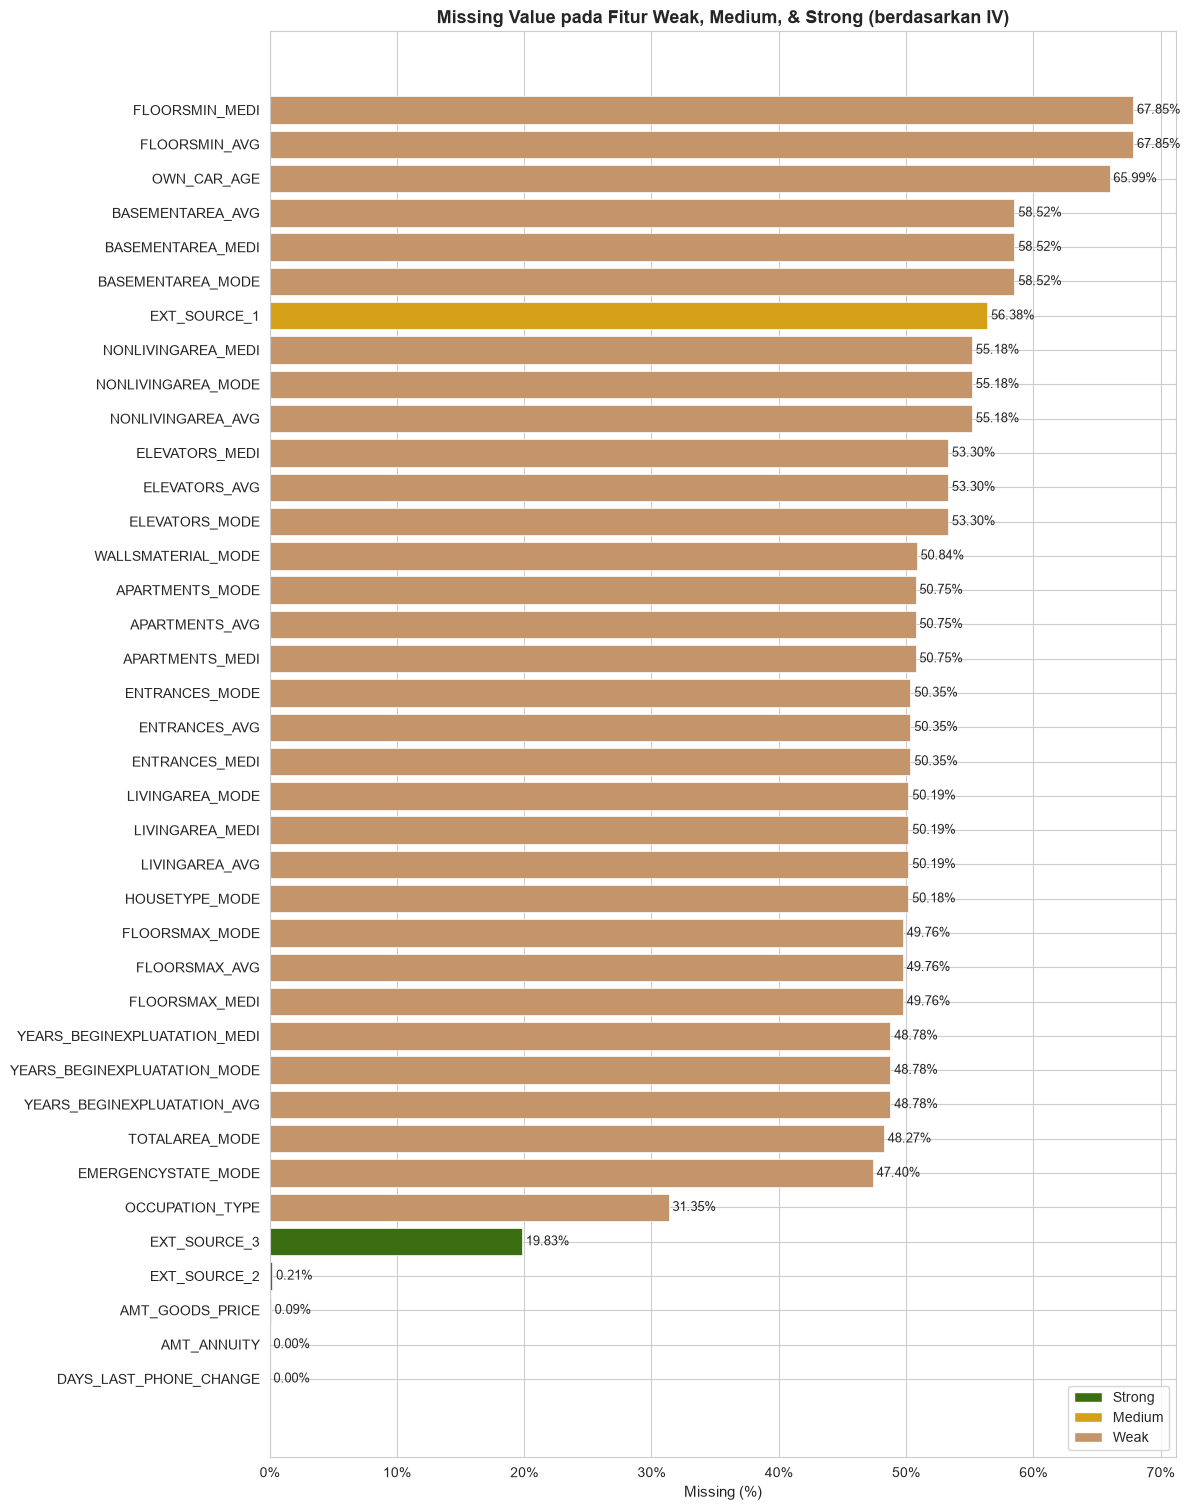

In [25]:
# =============================================
# Missing Value Analysis: Kolom Weak, Medium, Strong (berdasarkan IV)
# =============================================

# Filter kolom berdasarkan kategori IV
weak_cols   = iv_df_all[iv_df_all["category"] == "Weak"].index.tolist()
medium_cols = iv_df_all[iv_df_all["category"] == "Medium"].index.tolist()
strong_cols = iv_df_all[iv_df_all["category"] == "Strong"].index.tolist()

print(f"Jumlah kolom Weak  : {len(weak_cols)}")
print(f"Jumlah kolom Medium: {len(medium_cols)}")
print(f"Jumlah kolom Strong: {len(strong_cols)}")
print("=" * 70)

# --- Fungsi helper untuk missing value summary ---
def missing_summary(df, cols, label):
    """Buat summary missing value untuk daftar kolom."""
    if not cols:
        print(f"\n[{label}] — Tidak ada kolom dalam kategori ini.\n")
        return pd.DataFrame()

    miss = df[cols].isnull().sum()
    miss_pct = (miss / len(df)) * 100
    summary = pd.DataFrame({
        "missing_count": miss,
        "missing_pct (%)": miss_pct.round(2),
        "IV": iv_df_all.loc[cols, "information_value"].round(6),
        "dtype": iv_df_all.loc[cols, "dtype"]
    }).sort_values("missing_pct (%)", ascending=False)

    print(f"\n{'='*70}")
    print(f" [{label}] Missing Value — {len(cols)} kolom")
    print(f"{'='*70}")
    summary_display = summary.copy()
    summary_display["missing_pct (%)"] = summary_display["missing_pct (%)"].apply(lambda x: f"{x:.2f}%")
    print(summary_display.to_string())
    return summary

# --- Tampilkan summary per kategori ---
summary_strong = missing_summary(df, strong_cols, "STRONG (IV ≥ 0.3)")
summary_medium = missing_summary(df, medium_cols, "MEDIUM (0.1 ≤ IV < 0.3)")
summary_weak   = missing_summary(df, weak_cols,   "WEAK (0.02 ≤ IV < 0.1)")

# --- Visualisasi Missing Value per Kategori IV ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

all_summaries = []
for label, s in [("Strong", summary_strong), ("Medium", summary_medium), ("Weak", summary_weak)]:
    if not s.empty:
        s = s.copy()
        s["iv_category"] = label
        all_summaries.append(s)

if all_summaries:
    combined = pd.concat(all_summaries)
    combined = combined[combined["missing_count"] > 0].sort_values("missing_pct (%)", ascending=True)

    if not combined.empty:
        cat_colors = {"Strong": "#3B6D11", "Medium": "#D4A017", "Weak": "#C4956A"}
        colors = [cat_colors[c] for c in combined["iv_category"]]

        fig, ax = plt.subplots(figsize=(12, max(4, len(combined) * 0.4)))
        bars = ax.barh(combined.index, combined["missing_pct (%)"], color=colors, edgecolor="white", linewidth=0.5)

        # Annotate bars
        # Annotate bars dengan persen
        for bar, pct in zip(bars, combined["missing_pct (%)"]):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f"{pct:.2f}%", va="center", fontsize=9)

        ax.set_xlabel("Missing (%)", fontsize=11)
        ax.set_title("Missing Value pada Fitur Weak, Medium, & Strong (berdasarkan IV)", fontsize=13, fontweight="bold")
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))


        # Legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=cat_colors[k], label=k) for k in ["Strong", "Medium", "Weak"]]
        ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

        plt.tight_layout()
        plt.show()
    else:
        print("\n✅ Semua kolom Weak/Medium/Strong tidak memiliki missing value.")


# Kombinasi Missing Value % dengan Korelasi terhadap TARGET

data yang di peroleh memiliki aturan dimana aturannya nilai IV harus masuk ke TOP 10 dan Missing valuenya ada di bawah 51% 

Note: EXT_SOURCE 1 harus di masukan karena PENTING


 TOP 10 FITUR: Missing Value < 51% & IV Tertinggi
                              information_value missing_pct        dtype category
EXT_SOURCE_3                           0.329443      19.83%      numeric   Strong
EXT_SOURCE_2                           0.306473       0.21%      numeric   Strong
DAYS_EMPLOYED                          0.101263       0.00%      numeric   Medium
AMT_GOODS_PRICE                        0.091941       0.09%      numeric     Weak
DAYS_BIRTH                             0.084200       0.00%      numeric     Weak
OCCUPATION_TYPE                        0.082865      31.35%  categorical     Weak
ORGANIZATION_TYPE                      0.073368       0.00%  categorical     Weak
NAME_INCOME_TYPE                       0.059715       0.00%  categorical     Weak
NAME_EDUCATION_TYPE                    0.050836       0.00%  categorical     Weak
DAYS_LAST_PHONE_CHANGE                 0.046729       0.00%      numeric     Weak
AMT_CREDIT                             0.045073 

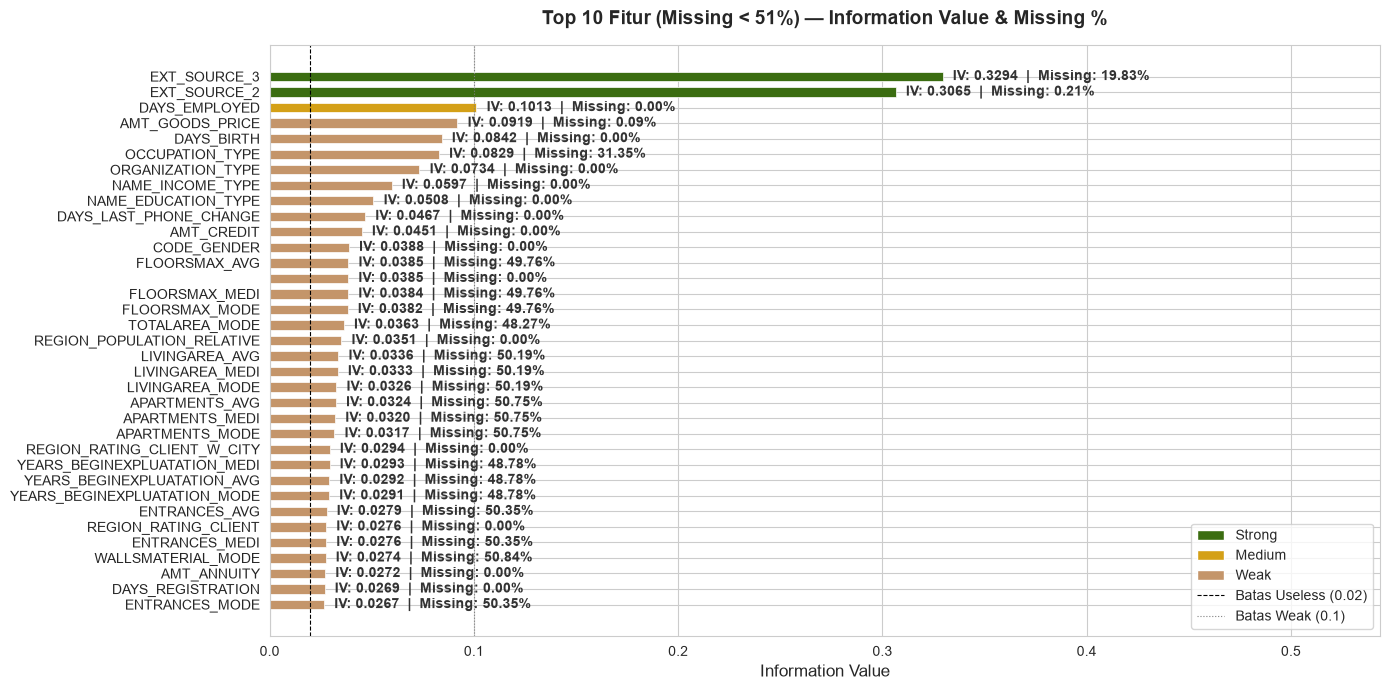

In [29]:
# =============================================
# Top 10 Fitur (Missing < 51%) — Satu Gambar Lengkap
# =============================================

all_feature_cols = [c for c in df.columns if c not in ["SK_ID_CURR", "TARGET"]]
miss_pct = (df[all_feature_cols].isnull().sum() / len(df) * 100).round(2)

result = iv_df_all.copy()
result["missing_pct"] = miss_pct

filtered = result[result["missing_pct"] < 51].copy()
top10 = filtered.sort_values("information_value", ascending=False).head(35)

print("=" * 75)
print(" TOP 10 FITUR: Missing Value < 51% & IV Tertinggi")
print("=" * 75)
display_df = top10.copy()
display_df["missing_pct"] = display_df["missing_pct"].apply(lambda x: f"{x:.2f}%")
display_df["information_value"] = display_df["information_value"].round(6)
print(display_df[["information_value", "missing_pct", "dtype", "category"]].to_string())

# --- Visualisasi 1 Gambar ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plot_data = top10.sort_values("information_value", ascending=True)

cat_colors = {"Strong": "#3B6D11", "Medium": "#D4A017", "Weak": "#C4956A"}
colors = [cat_colors.get(c, "gray") for c in plot_data["category"]]

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar utama: Information Value
bars = ax1.barh(plot_data.index, plot_data["information_value"], color=colors,
                edgecolor="white", linewidth=0.5, height=0.6)

# Anotasi: IV + Missing % di samping bar
for bar, iv, mp, cat in zip(bars, plot_data["information_value"],
                             plot_data["missing_pct"], plot_data["category"]):
    y_pos = bar.get_y() + bar.get_height() / 2
    ax1.text(bar.get_width() + 0.005, y_pos,
             f"IV: {iv:.4f}  |  Missing: {mp:.2f}%",
             va="center", fontsize=10, fontweight="bold", color="#333333")

ax1.set_xlabel("Information Value", fontsize=12)
ax1.set_title("Top 10 Fitur (Missing < 51%) — Information Value & Missing %",
              fontsize=14, fontweight="bold", pad=15)
ax1.axvline(0.02, color="black", linestyle="--", linewidth=0.8, label="Batas Useless (0.02)")
ax1.axvline(0.1, color="gray", linestyle=":", linewidth=0.8, label="Batas Weak (0.1)")

# Beri ruang untuk anotasi teks di kanan
ax1.set_xlim(0, plot_data["information_value"].max() * 1.65)

# Legend
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=cat_colors[k], label=k)
             for k in ["Strong", "Medium", "Weak"]
             if k in plot_data["category"].values]
legend_el += ax1.get_legend_handles_labels()[0]
ax1.legend(handles=legend_el, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()


# Distribusi Fitur Numerik Kunci & Anomali

Tujuan: memahami sebaran fitur finansial utama (income, credit amount, annuity) dan 
skor eksternal (EXT_SOURCE_1/2/3) yang biasanya menjadi prediktor terkuat di dataset 
ini. Khusus DAYS_EMPLOYED, dataset ini punya sentinel anomaly value (365243 hari, 
setara ~1000 tahun) yang harus dideteksi dulu sebelum dianalisis atau dimodelkan, 
karena bisa merusak statistik deskriptif.

In [ ]:
numeric_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
                 "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_EMPLOYED"]

print(df[numeric_cols].describe())

anomaly_flag = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\nJumlah baris dengan DAYS_EMPLOYED anomaly (365243): {anomaly_flag} "
      f"({anomaly_flag/len(df)*100:.2f}%)")     

       AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY   EXT_SOURCE_1  \
count      3.075110e+05  3.075110e+05  307499.000000  134133.000000   
mean       1.687979e+05  5.990260e+05   27108.573909       0.502130   
std        2.371231e+05  4.024908e+05   14493.737315       0.211062   
min        2.565000e+04  4.500000e+04    1615.500000       0.014568   
25%        1.125000e+05  2.700000e+05   16524.000000       0.334007   
50%        1.471500e+05  5.135310e+05   24903.000000       0.505998   
75%        2.025000e+05  8.086500e+05   34596.000000       0.675053   
max        1.170000e+08  4.050000e+06  258025.500000       0.962693   

       EXT_SOURCE_2   EXT_SOURCE_3  DAYS_EMPLOYED  
count  3.068510e+05  246546.000000  307511.000000  
mean   5.143927e-01       0.510853   63815.045904  
std    1.910602e-01       0.194844  141275.766519  
min    8.170000e-08       0.000527  -17912.000000  
25%    3.924574e-01       0.370650   -2760.000000  
50%    5.659614e-01       0.535276   -1213.00000

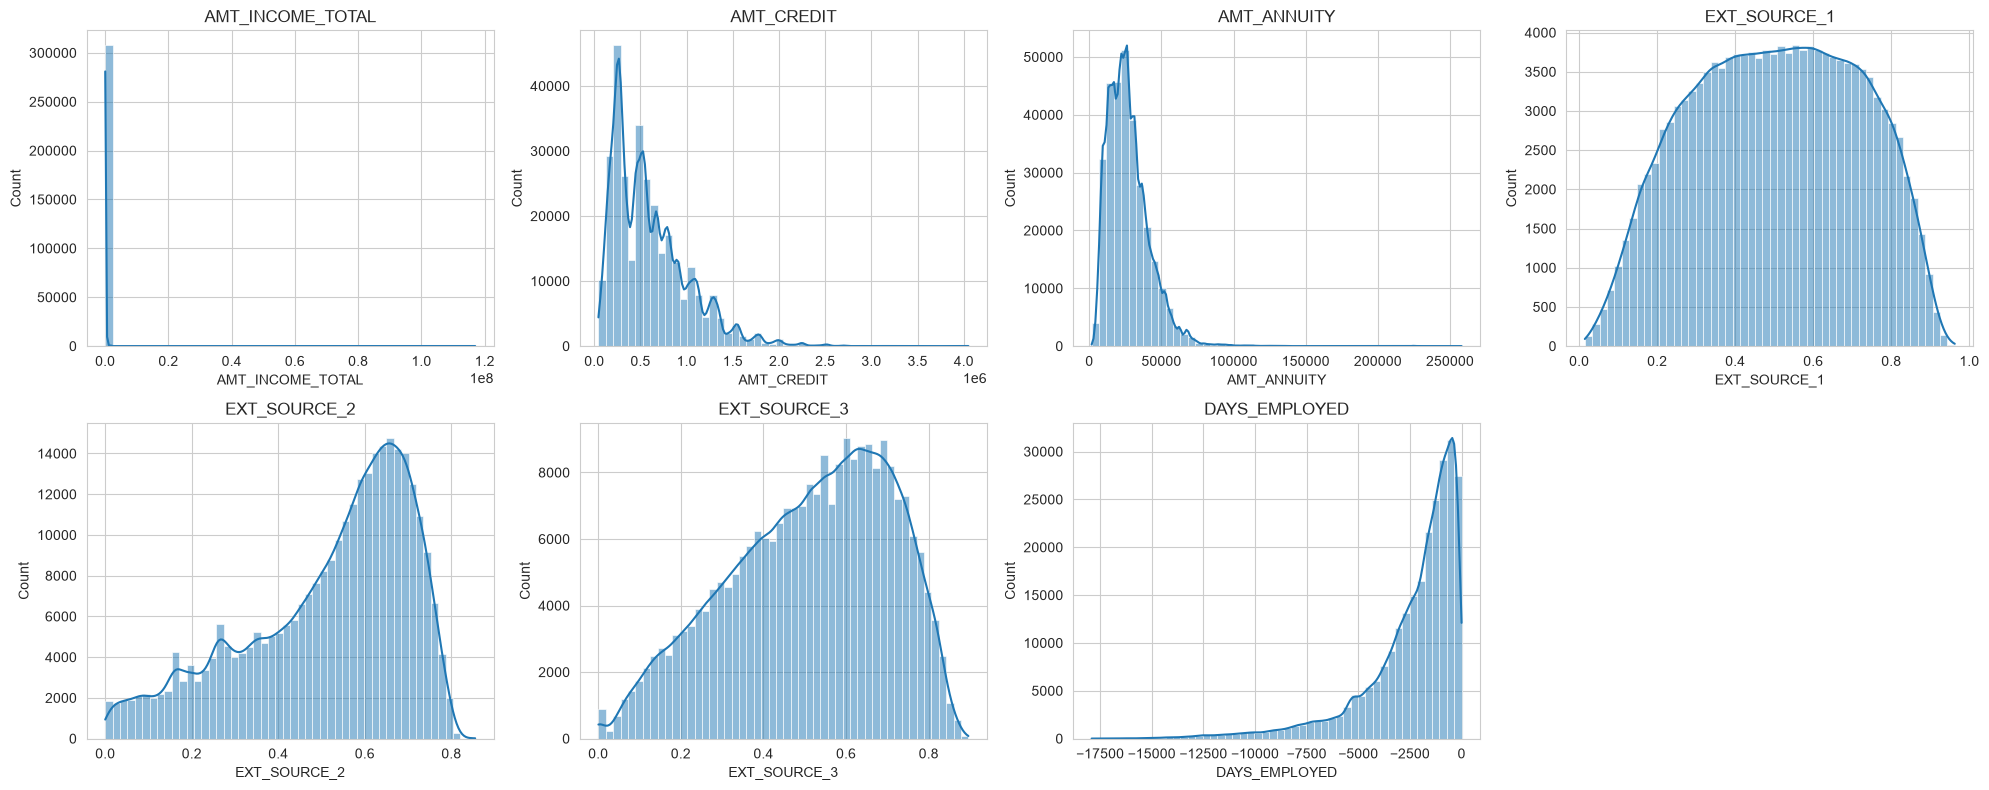

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_to_plot = df[col].dropna()
    if col == "DAYS_EMPLOYED":
        data_to_plot = data_to_plot[data_to_plot != 365243]
    sns.histplot(data_to_plot, kde=True, ax=axes[i], bins=50)
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/03_numeric_distributions.png", dpi=150)
plt.show()

# Fitur Kategorikal vs TARGET

Tujuan: mengidentifikasi kategori dengan default rate yang berbeda signifikan. 
Hasil ini menjadi dasar business recommendation ke stakeholder non-teknis 
(misal: "klien dengan status X punya risiko default 2x lebih tinggi").

In [14]:
categorical_cols = ["NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_INCOME_TYPE"]

for col in categorical_cols:
    rate = df.groupby(col)["TARGET"].mean().sort_values(ascending=False) * 100
    print(f"\nDefault rate berdasarkan {col}:")
    print(rate.round(2))


Default rate berdasarkan NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64

Default rate berdasarkan NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Civil marriage          9.94
Single / not married    9.81
Separated               8.19
Married                 7.56
Widow                   5.82
Unknown                 0.00
Name: TARGET, dtype: float64

Default rate berdasarkan NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Maternity leave         40.00
Unemployed              36.36
Working                  9.59
Commercial associate     7.48
State servant            5.75
Pensioner                5.39
Businessman              0.00
Student                  0.00
Name: TARGET, dtype: float64


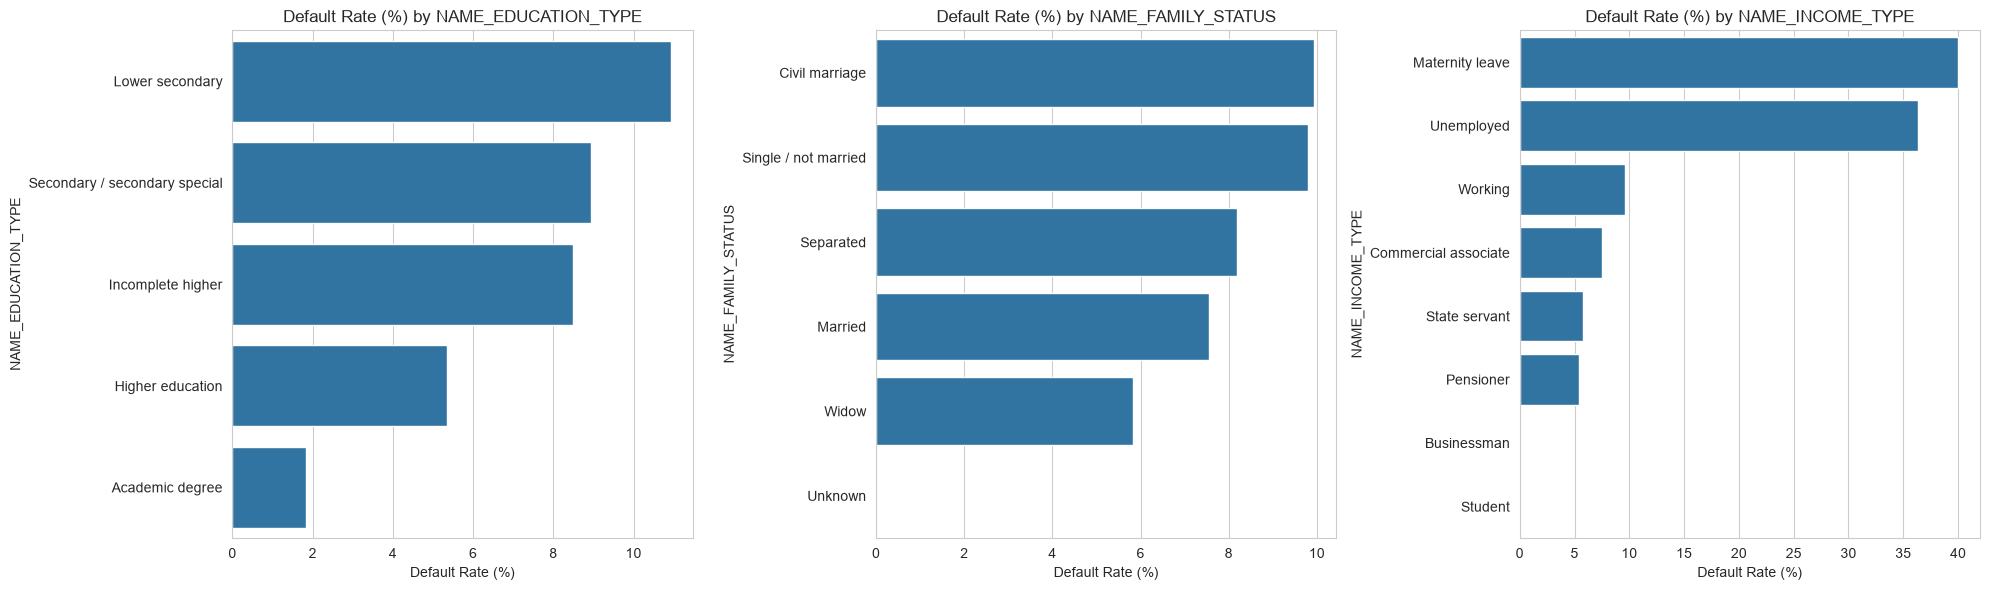

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    rate = df.groupby(col)["TARGET"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i])
    axes[i].set_title(f"Default Rate (%) by {col}")
    axes[i].set_xlabel("Default Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/04_categorical_vs_target.png", dpi=150)
plt.show()

# Korelasi Antar Fitur Numerik & terhadap TARGET

Tujuan: mendeteksi multikolinearitas antar fitur (penting untuk interpretasi model 
linear/SHAP) dan mengidentifikasi fitur numerik paling berkorelasi dengan TARGET 
sebagai kandidat prioritas di feature engineering.

In [16]:
numeric_for_corr = df.select_dtypes(include=[np.number]).drop(columns=["SK_ID_CURR"])

corr_with_target = numeric_for_corr.corr()["TARGET"].sort_values()
print("Top 10 korelasi negatif (fitur pelindung dari default):")
print(corr_with_target.head(10))
print("\nTop 10 korelasi positif (fitur peningkat risiko default):")
print(corr_with_target.tail(11)[:-1])

Top 10 korelasi negatif (fitur pelindung dari default):
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Top 10 korelasi positif (fitur peningkat risiko default):
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
                               0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64


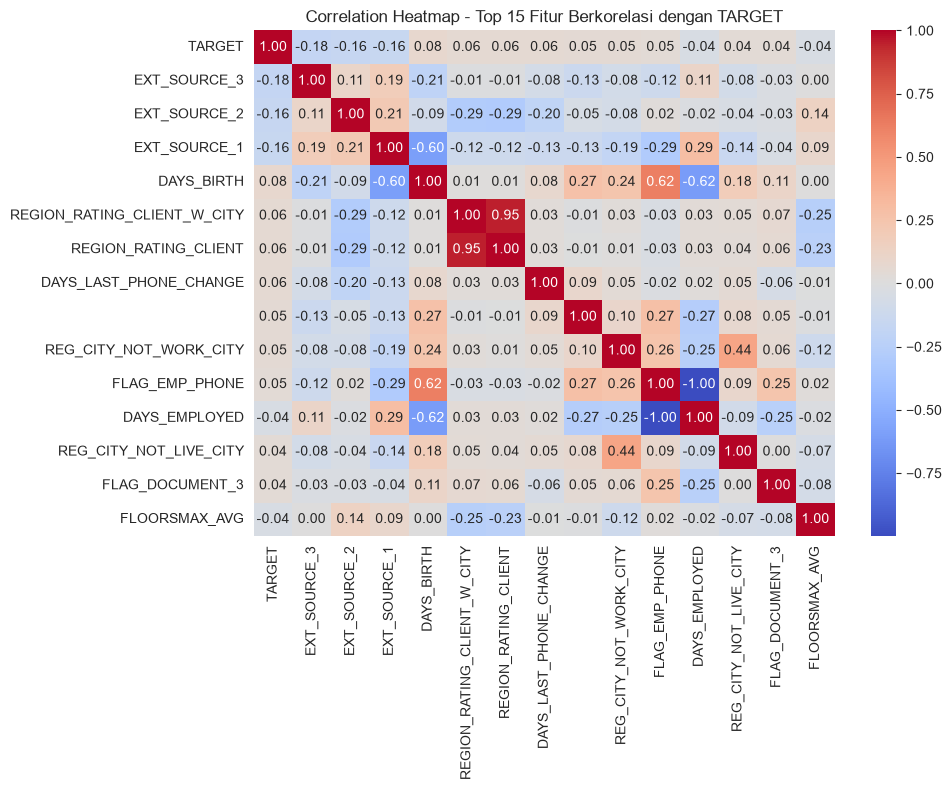

In [17]:
top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_for_corr[top_corr_features].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap - Top 15 Fitur Berkorelasi dengan TARGET")
plt.tight_layout()
plt.savefig("../reports/figures/05_correlation_heatmap.png", dpi=150)
plt.show()

# Deteksi Outlier Fitur Finansial

Tujuan: nilai ekstrem pada income/credit amount bisa mendistorsi statistik deskriptif 
dan model berbasis jarak (meski tree-based model relatif tahan outlier). Keputusan 
di sini (cap, log-transform, atau biarkan) akan memengaruhi desain preprocessing 
di tahap Data Cleaning.

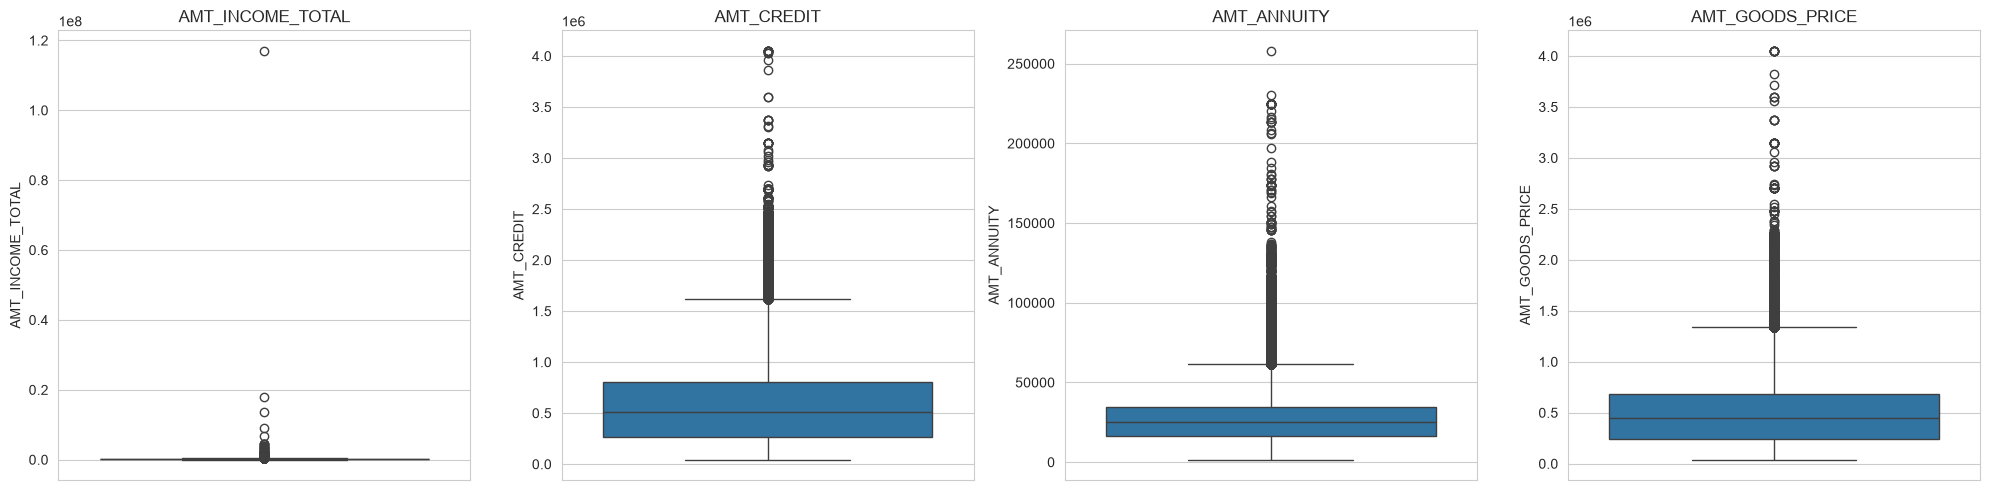

AMT_INCOME_TOTAL: 14035 outlier (4.56%), batas atas IQR = 337,500
AMT_CREDIT: 6562 outlier (2.13%), batas atas IQR = 1,616,625
AMT_ANNUITY: 7504 outlier (2.44%), batas atas IQR = 61,704
AMT_GOODS_PRICE: 14728 outlier (4.79%), batas atas IQR = 1,341,000


In [18]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(financial_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("../reports/figures/06_outlier_boxplots.png", dpi=150)
plt.show()

for col in financial_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper_bound).sum()
    print(f"{col}: {n_outliers} outlier ({n_outliers/len(df)*100:.2f}%), "
          f"batas atas IQR = {upper_bound:,.0f}")

# Cardinality Check Fitur Kategorikal

Tujuan: fitur dengan cardinality tinggi (banyak kategori unik) butuh strategi encoding 
berbeda dibanding fitur dengan cardinality rendah. One-hot encoding cocok untuk 
cardinality rendah, sedangkan target/frequency encoding lebih cocok untuk cardinality 
tinggi seperti ORGANIZATION_TYPE atau OCCUPATION_TYPE.

In [19]:
categorical_all = df.select_dtypes(include="object").columns

cardinality = df[categorical_all].nunique().sort_values(ascending=False)
print("Cardinality tiap fitur kategorikal:")
print(cardinality)

Cardinality tiap fitur kategorikal:
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_21396\3774824920.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_all = df.select_dtypes(include="object").columns


#  Distribusi Umur vs TARGET

Tujuan: DAYS_BIRTH bernilai negatif (hari sebelum tanggal aplikasi), perlu dikonversi 
ke tahun. Umur sering menjadi segmen risiko penting di industri finansial nyata, 
baik sebagai fitur model maupun narasi bisnis ke stakeholder (misal: "klien usia 
20-25 tahun punya risiko default lebih tinggi").

C:\Users\USER\AppData\Local\Temp\ipykernel_21396\2387346331.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)


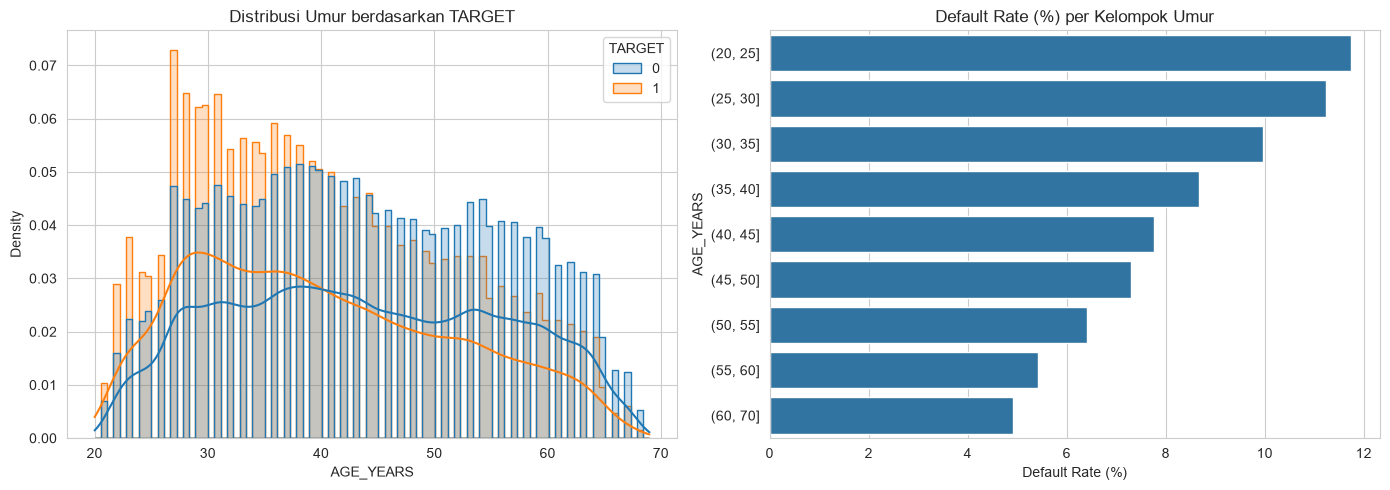

In [20]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="AGE_YEARS", hue="TARGET", kde=True, ax=axes[0],
             element="step", stat="density", common_norm=False)
axes[0].set_title("Distribusi Umur berdasarkan TARGET")

age_bins = pd.cut(df["AGE_YEARS"], bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70])
age_default_rate = df.groupby(age_bins, observed=True)["TARGET"].mean() * 100
sns.barplot(x=age_default_rate.values, y=age_default_rate.index.astype(str), ax=axes[1])
axes[1].set_title("Default Rate (%) per Kelompok Umur")
axes[1].set_xlabel("Default Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/08_age_vs_target.png", dpi=150)
plt.show()